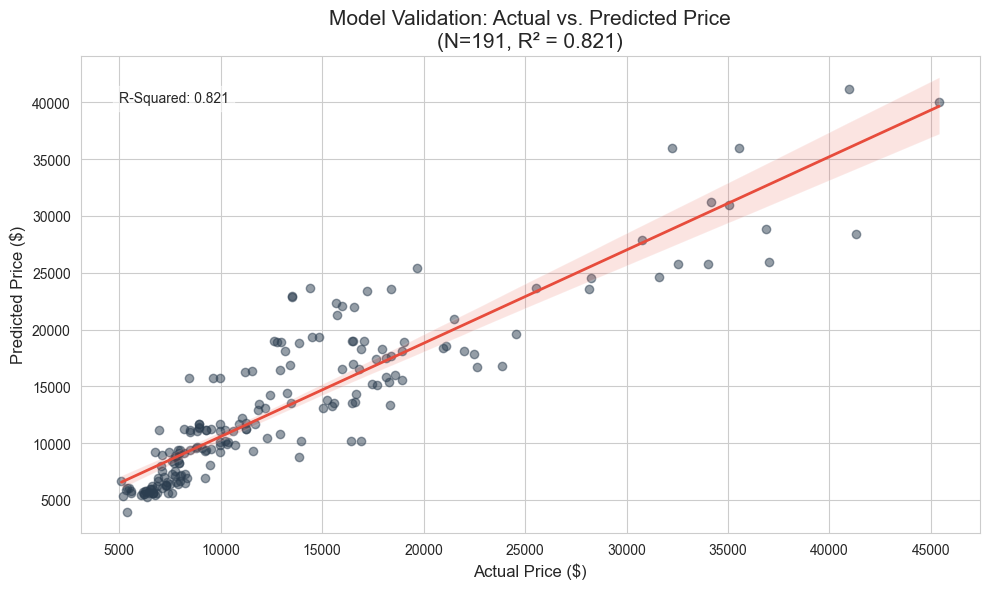

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. Load Data
cols = ["symboling", "normalized_losses", "make", "fuel_type", "aspiration", 
        "num_doors", "body_style", "drive_wheels", "engine_location", "wheel_base", 
        "length", "width", "height", "curb_weight", "engine_type", "num_cylinders", 
        "engine_size", "fuel_system", "bore", "stroke", "compression_ratio", 
        "horsepower", "peak_rpm", "city_mpg", "highway_mpg", "price"]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
df = pd.read_csv(url, names=cols, na_values="?")

# 2. THE CLEANING LOGIC
# Drop rows with missing values in key columns
df = df.dropna(subset=["price", "horsepower", "peak_rpm", "bore", "stroke", "num_doors"])
# Remove outliers (3 and 12 cylinders) to reach exactly 191 rows
df = df[~df['num_cylinders'].isin(['three', 'twelve'])]

# 3. Model Training
features = ['horsepower', 'engine_size', 'curb_weight', 'city_mpg']
X = df[features]
y = df['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)
df['Predicted_Price'] = model.predict(X_scaled)

# Calculate R-Squared for the plot
r2 = r2_score(y, df['Predicted_Price'])

# 4. PLOTTING THE GRAPH
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the scatter plot with regression line
ax = sns.regplot(x='price', y='Predicted_Price', data=df, 
                 scatter_kws={'alpha':0.5, 'color':'#2c3e50'}, 
                 line_kws={'color':'#e74c3c', 'lw':2})

# Formatting
plt.title(f'Model Validation: Actual vs. Predicted Price\n(N=191, R² = {r2:.3f})', fontsize=15)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)

# Add a text box with the R-squared value
plt.text(5000, 40000, f'R-Squared: {r2:.3f}', bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()